# 🍷 Wine Quality Prediction

## Oasis Infobyte Data Analytics Internship – Level 2

### Objective

The objective of this project is to build and compare multiple machine learning classification models to predict the quality of red wine based on its physicochemical properties such as acidity, density, pH, sulphates, and alcohol content.

This project includes:

- Data Loading and Inspection
- Exploratory Data Analysis (EDA)
- Class Imbalance Analysis
- Feature Engineering
- Data Preprocessing
- Model Building using:
  - Random Forest Classifier
  - Stochastic Gradient Descent (SGD) Classifier
  - Support Vector Classifier (SVC)
- Model Evaluation
- Feature Importance Analysis
- Performance Comparison
- Conclusion

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [103]:
# ============================
# Import Required Libraries
# ============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [104]:
# ============================
# Notebook Settings
# ============================

# Display all columns
pd.set_option("display.max_columns", None)

# Display numbers up to 3 decimal places
pd.set_option("display.float_format", "{:.3f}".format)

# Plot settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Figure size
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [105]:
# ============================
# Load the Dataset
# ============================

# Load the dataset
df = pd.read_csv("WineQuality-RedWine.csv", encoding="utf-16")

# Display the first five rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5


In [106]:
# ============================
# Check Missing Values
# ============================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
missing_values

Missing Values in Each Column:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [107]:
# ============================
# Check Duplicate Records
# ============================

duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 240


In [108]:
# ============================
# Remove Duplicate Records
# ============================

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1359, 12)


In [109]:
# ============================
# Data Cleaning Summary
# ============================

print("Final Dataset Shape :", df.shape)
print("Missing Values      :", df.isnull().sum().sum())
print("Duplicate Rows      :", df.duplicated().sum())

Final Dataset Shape : (1359, 12)
Missing Values      : 0
Duplicate Rows      : 0


# Exploratory Data Analysis (EDA)

In [110]:
# ============================
# Quality Score Distribution
# ============================

quality_counts = df["quality"].value_counts().sort_index()

print("Quality Score Distribution:")
print(quality_counts)

Quality Score Distribution:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


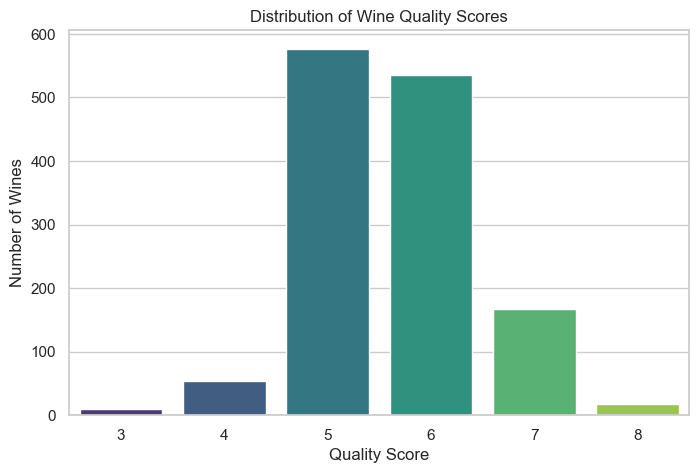

In [111]:
# Plot the distribution of wine quality scores

plt.figure(figsize=(8,5))

sns.countplot(
    x="quality",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

In [112]:
# Percentage distribution of quality scores

quality_percentage = (
    df["quality"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

print("Percentage Distribution:")
print(quality_percentage)

Percentage Distribution:
quality
3    0.740
4    3.900
5   42.460
6   39.370
7   12.290
8    1.250
Name: proportion, dtype: float64


### Observation

- Most wines belong to quality scores **5** and **6**.
- Very few samples belong to quality **3** and **8**.
- The dataset is **imbalanced**, as some quality classes have significantly fewer samples.
- This class imbalance may affect the performance of machine learning models, especially for minority classes.

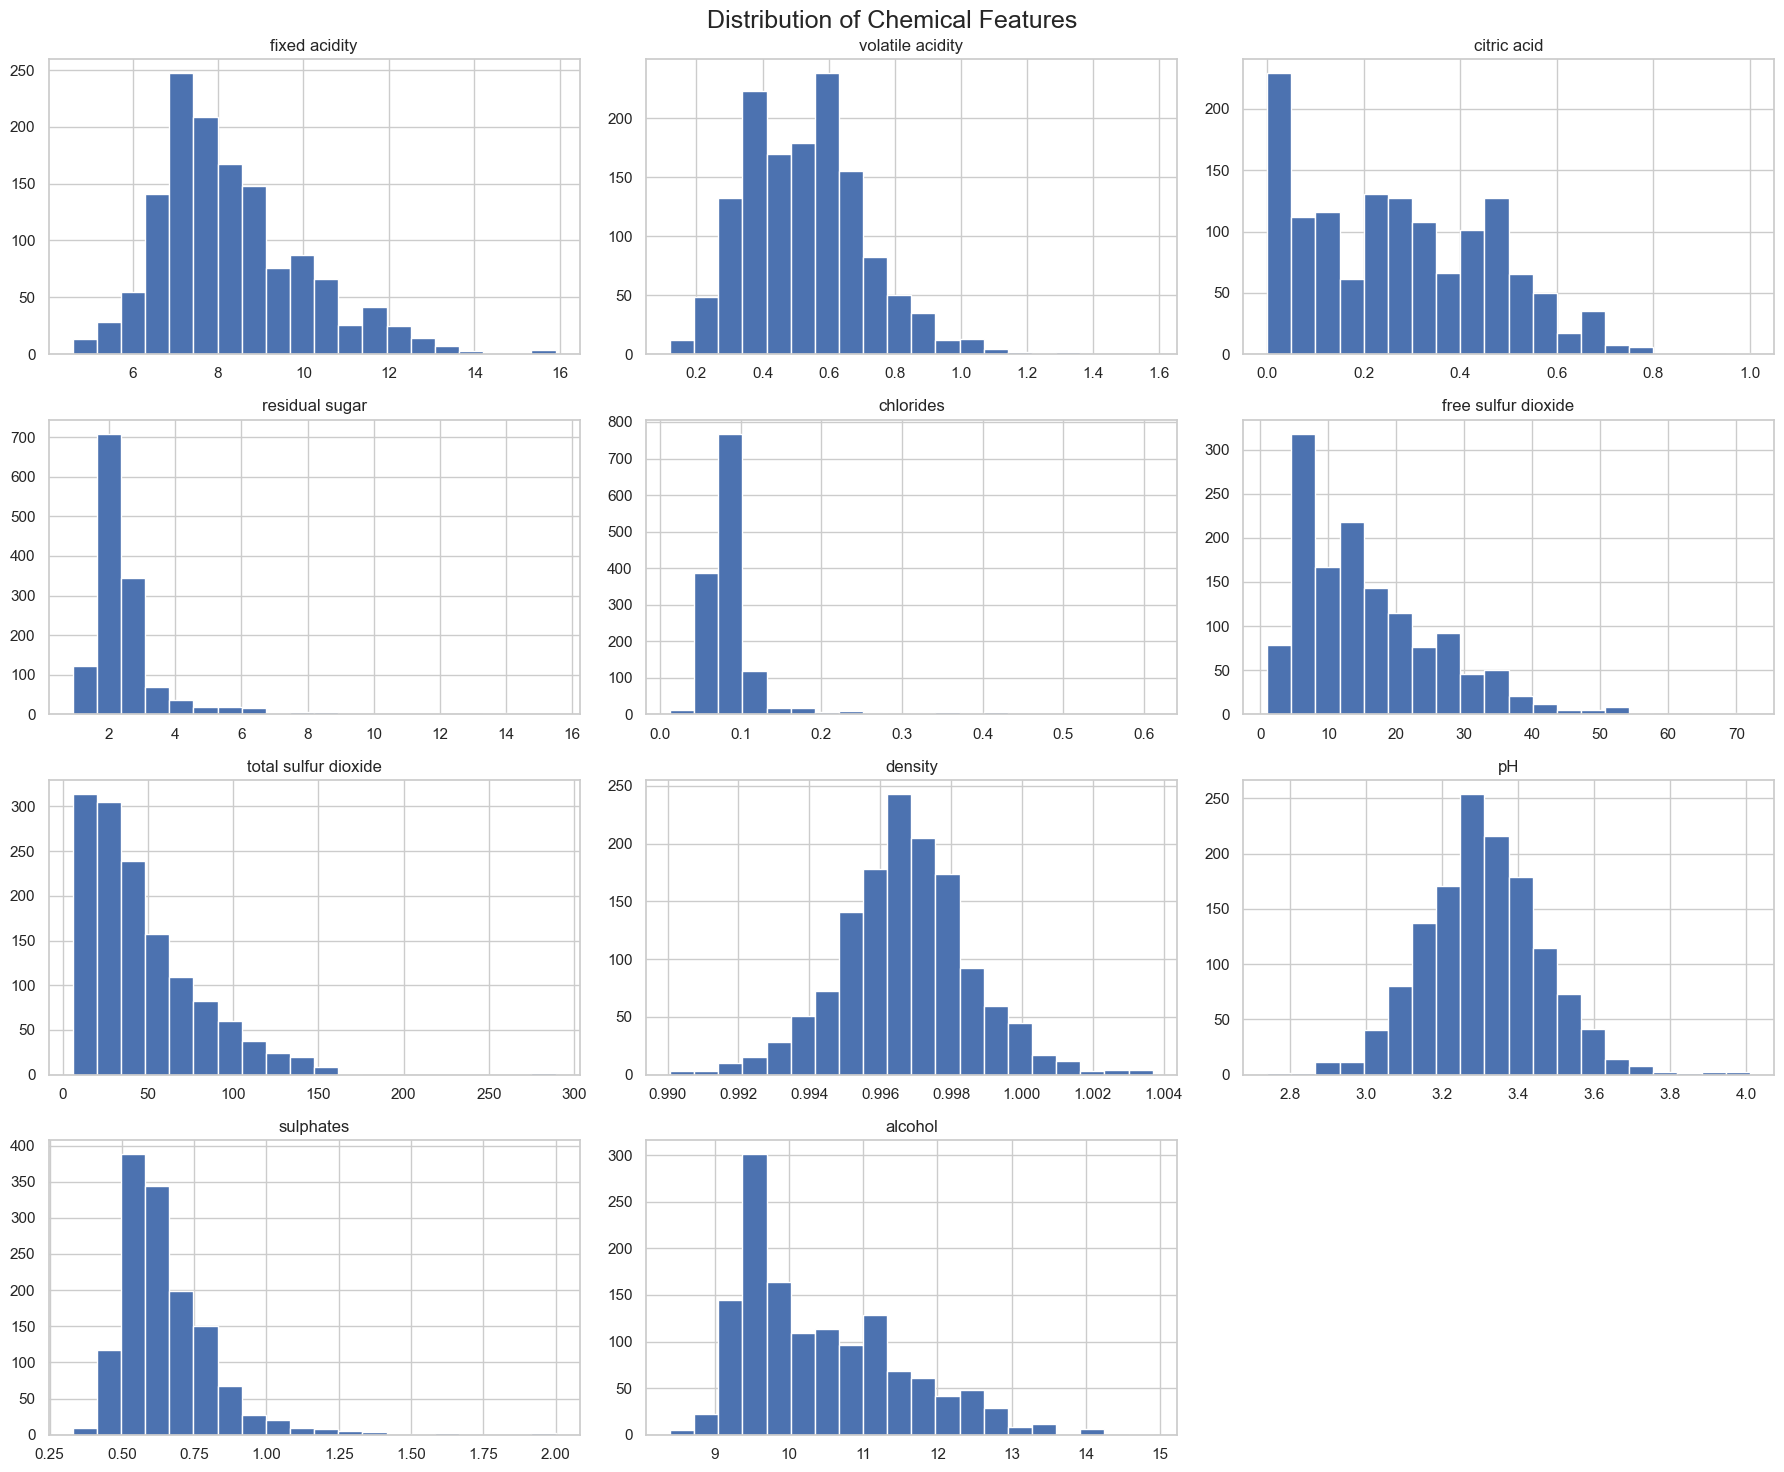

In [113]:
# ============================
# Distribution of Chemical Features
# ============================

# Exclude target column
features = df.drop("quality", axis=1)

# Plot histograms
features.hist(figsize=(18, 15), bins=20)

plt.suptitle("Distribution of Chemical Features", fontsize=18)

plt.tight_layout()

plt.show()

### Observations

- Most chemical features exhibit non-normal (skewed) distributions.
- Features such as **residual sugar**, **chlorides**, **free sulfur dioxide**, and **total sulfur dioxide** are positively skewed.
- **Density** and **pH** appear approximately normally distributed.
- **Alcohol** values are concentrated between 9% and 11.5%, with fewer samples at higher alcohol levels.
- These distributions indicate that feature scaling will be beneficial before training models such as SGD and SVC.

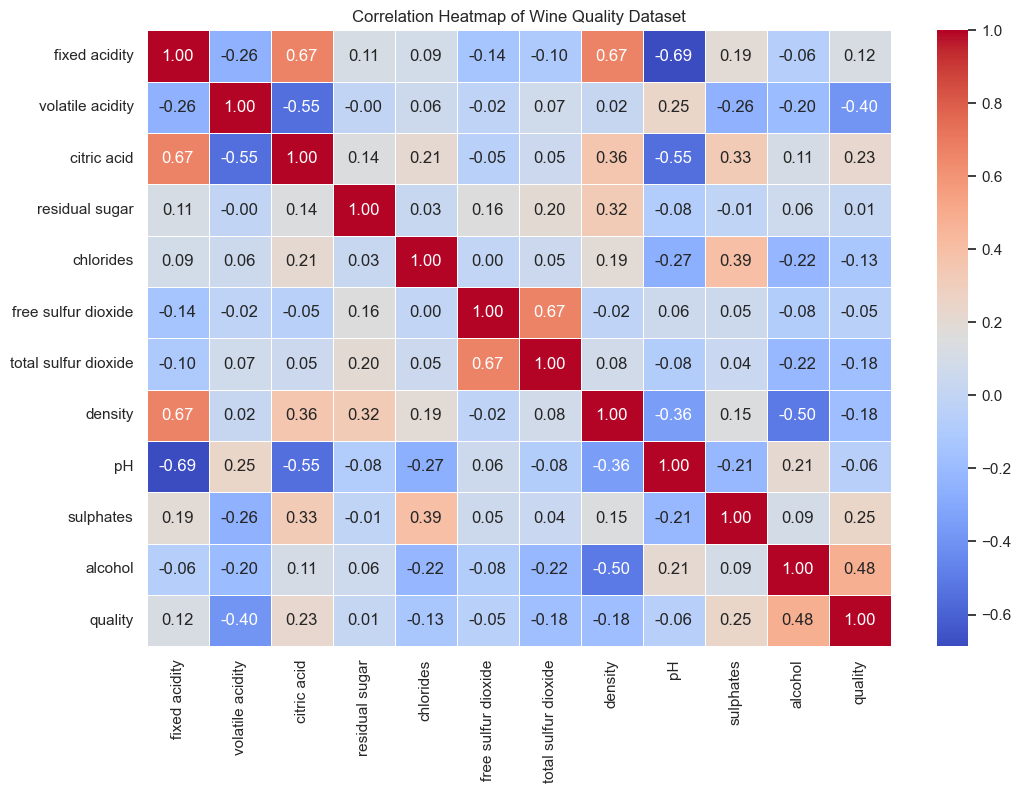

In [114]:
# ============================
# Correlation Heatmap
# ============================

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Dataset")

plt.show()

### Observations

- **Alcohol** has the strongest positive correlation with wine quality (**0.48**), indicating that wines with higher alcohol content tend to receive better quality ratings.
- **Volatile acidity** shows the strongest negative correlation with quality (**-0.40**), suggesting that higher volatile acidity is generally associated with lower wine quality.
- **Sulphates** (**0.25**) and **citric acid** (**0.23**) have a moderate positive correlation with quality.
- **Density** (**-0.18**) and **total sulfur dioxide** (**-0.18**) have weak negative correlations with quality.
- Most other features exhibit weak correlations, indicating that wine quality depends on a combination of multiple physicochemical properties rather than a single feature.

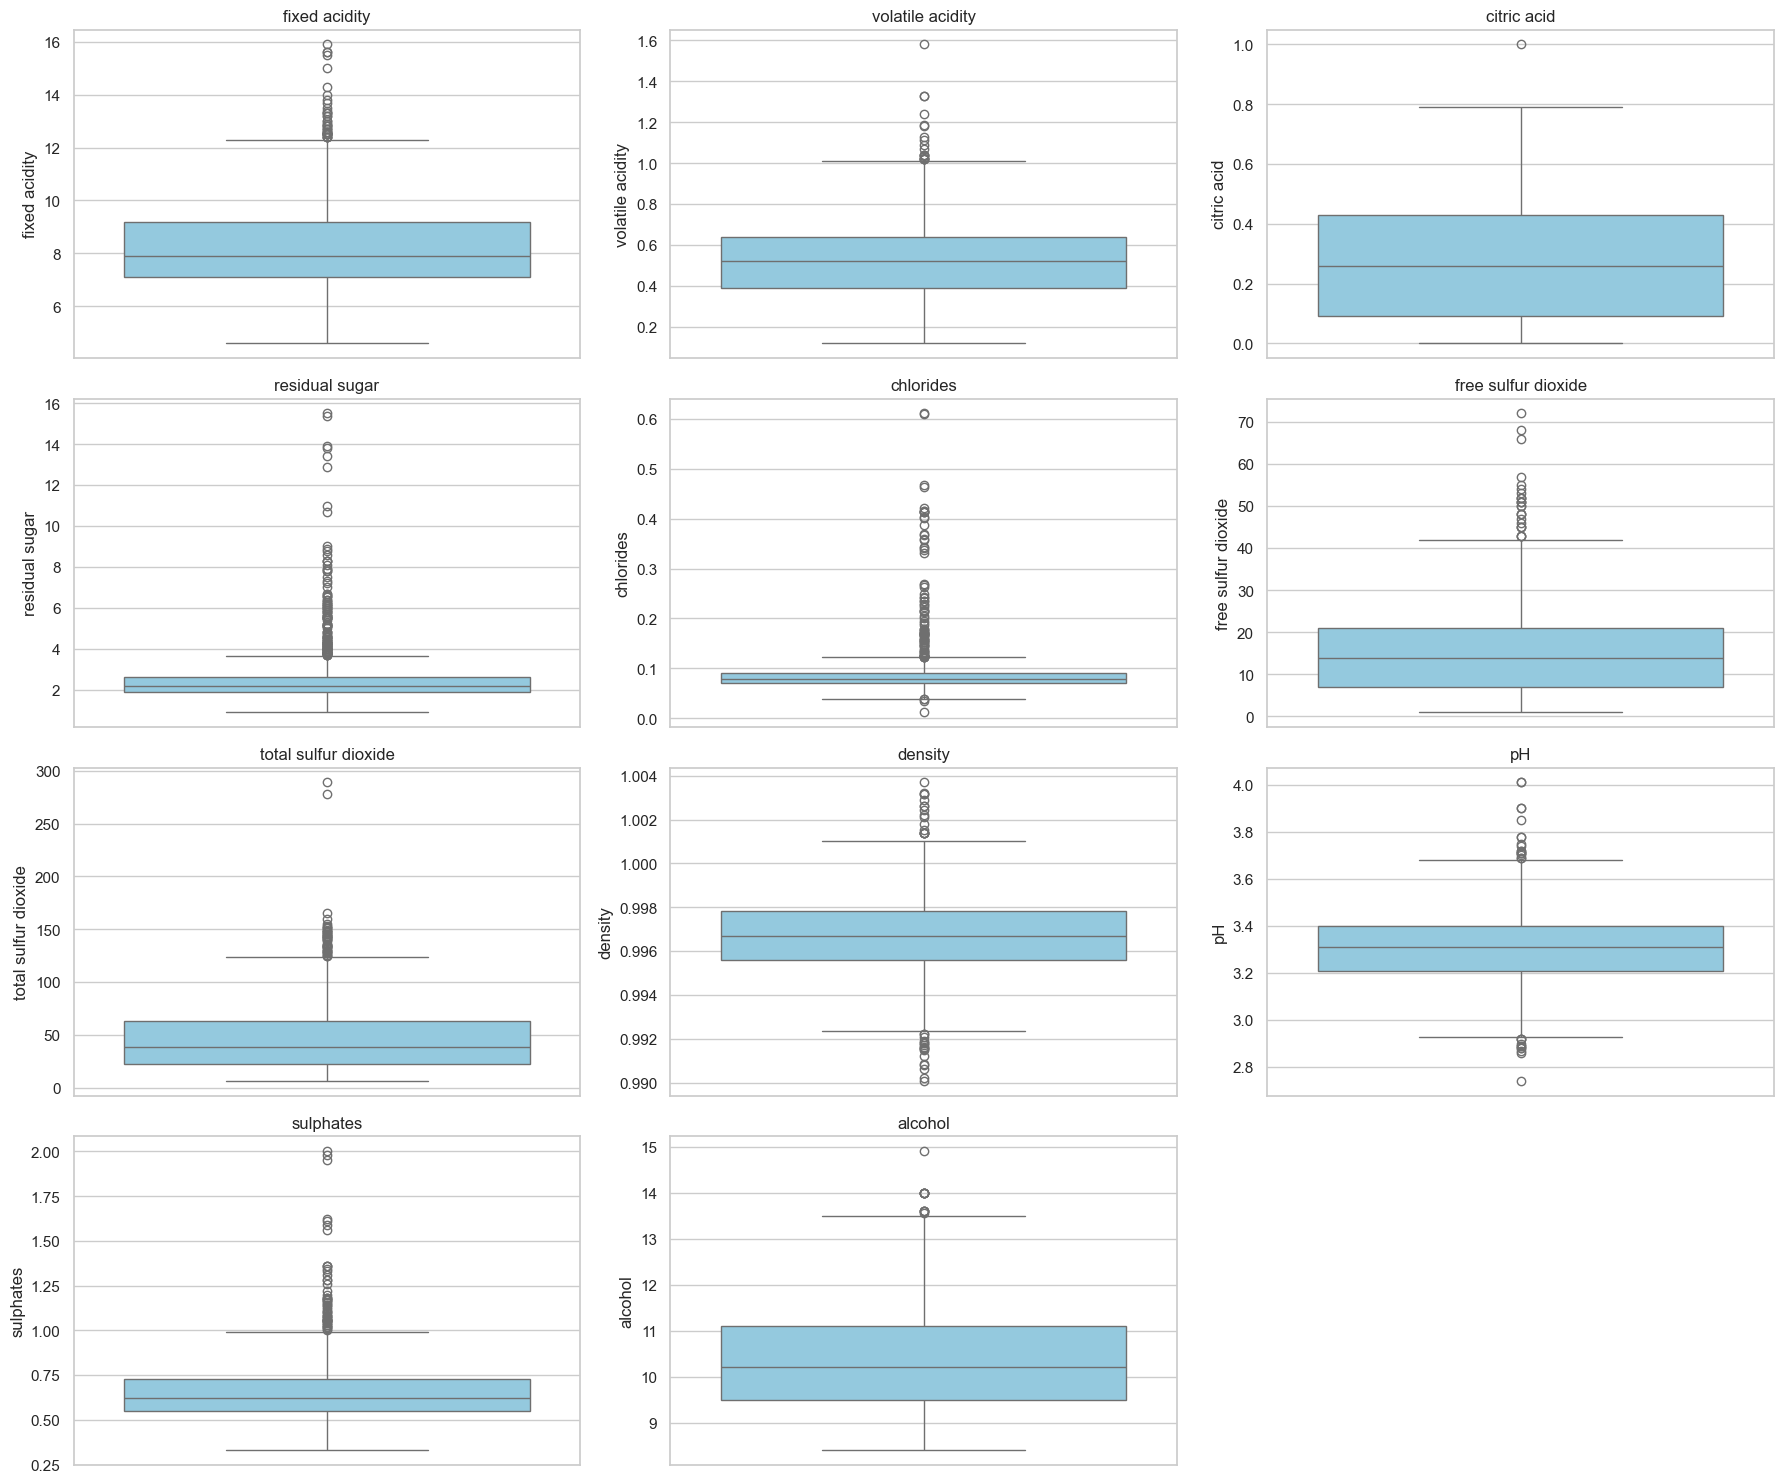

In [115]:
# ============================
# Boxplots for Numerical Features
# ============================

plt.figure(figsize=(18, 15))

for i, column in enumerate(df.columns[:-1], 1):   # Exclude 'quality'
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

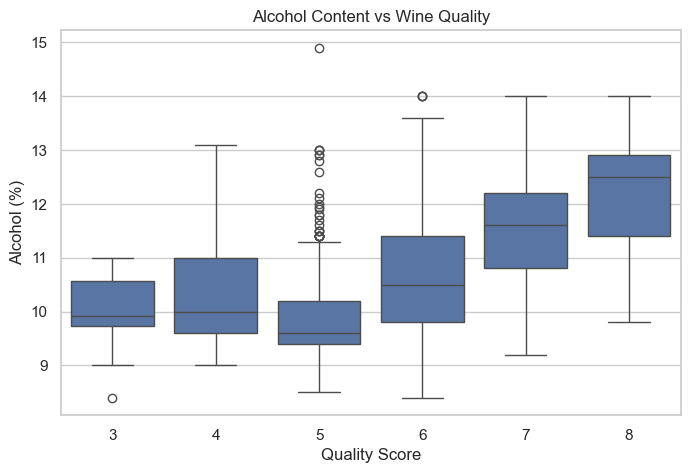

In [116]:
# ============================
# Alcohol vs Quality
# ============================

plt.figure(figsize=(8,5))

sns.boxplot(x="quality", y="alcohol", data=df)

plt.title("Alcohol Content vs Wine Quality")

plt.xlabel("Quality Score")
plt.ylabel("Alcohol (%)")

plt.show()

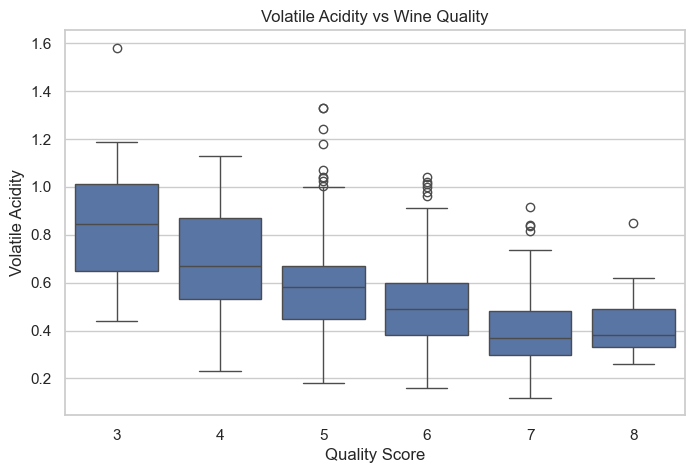

In [117]:
# ============================
# Volatile Acidity vs Quality
# ============================

plt.figure(figsize=(8,5))

sns.boxplot(x="quality", y="volatile acidity", data=df)

plt.title("Volatile Acidity vs Wine Quality")

plt.xlabel("Quality Score")
plt.ylabel("Volatile Acidity")

plt.show()

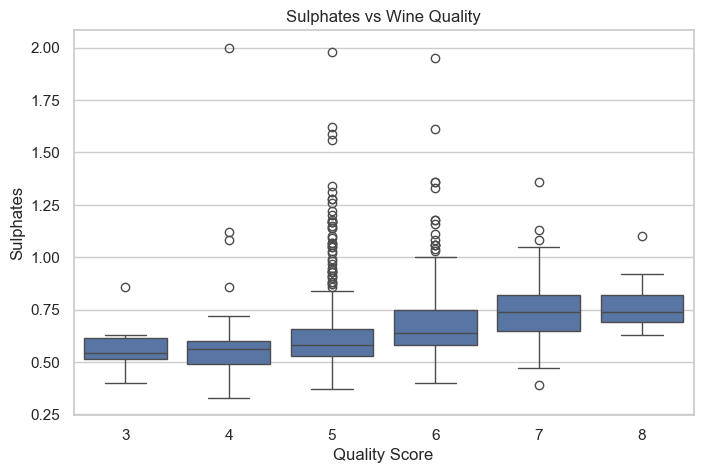

In [118]:
# ============================
# Sulphates vs Quality
# ============================

plt.figure(figsize=(8,5))

sns.boxplot(x="quality", y="sulphates", data=df)

plt.title("Sulphates vs Wine Quality")

plt.xlabel("Quality Score")
plt.ylabel("Sulphates")

plt.show()

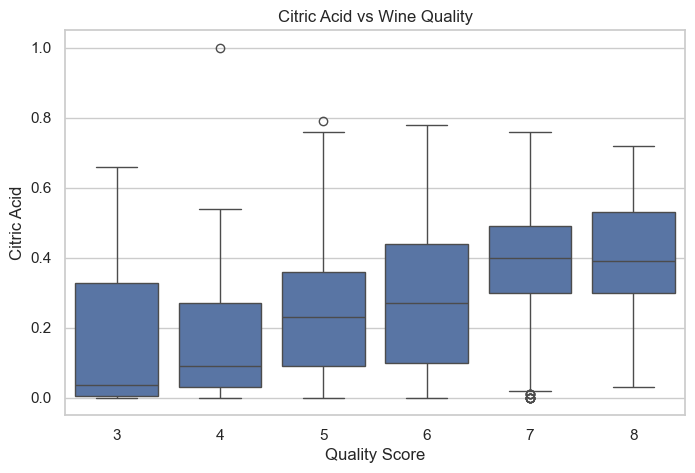

In [119]:
# ============================
# Citric Acid vs Quality
# ============================

plt.figure(figsize=(8,5))

sns.boxplot(x="quality", y="citric acid", data=df)

plt.title("Citric Acid vs Wine Quality")

plt.xlabel("Quality Score")
plt.ylabel("Citric Acid")

plt.show()

### Feature Relationship Observations

- Wines with higher **alcohol content** generally have higher quality scores.
- Higher **volatile acidity** is associated with lower wine quality.
- Wines with higher **sulphates** tend to receive better quality ratings.
- **Citric acid** shows a slight positive relationship with wine quality.
- These observations are consistent with the correlation analysis performed earlier.

# Feature Engineering

The original wine quality scores range from **3 to 8** and exhibit class imbalance, with most samples belonging to quality scores **5** and **6**.

To simplify the classification task and improve model performance, the target variable is converted into a binary classification problem:

- **Bad Wine (0):** Quality scores less than 6
- **Good Wine (1):** Quality scores greater than or equal to 6

This transformation helps reduce the impact of class imbalance and makes the prediction task more suitable for binary classification models.

In [120]:
# ============================
# Convert Quality into Binary Classes
# ============================

df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

print("Quality Labels Converted Successfully!")

Quality Labels Converted Successfully!


In [121]:
# ============================
# Binary Class Distribution
# ============================

df["quality"].value_counts()

quality
1    719
0    640
Name: count, dtype: int64

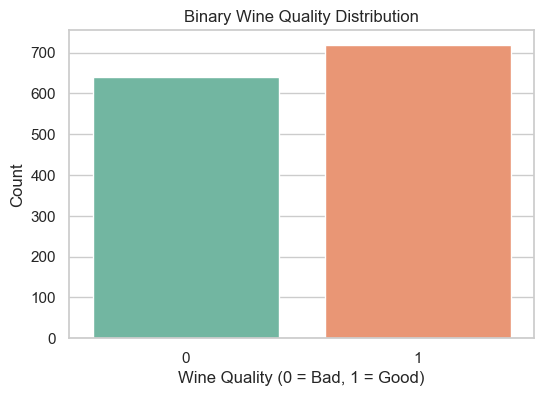

In [122]:
# ============================
# Binary Target Distribution
# ============================

plt.figure(figsize=(6,4))

sns.countplot(
    x="quality",
    data=df,
    palette="Set2"
)

plt.title("Binary Wine Quality Distribution")
plt.xlabel("Wine Quality (0 = Bad, 1 = Good)")
plt.ylabel("Count")


plt.show()

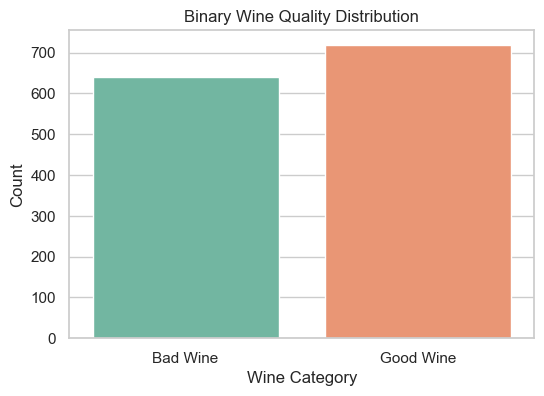

In [123]:
# ============================
# Binary Target Distribution
# ============================

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="quality",
    data=df,
    palette="Set2"
)

ax.set_xticklabels(["Bad Wine", "Good Wine"])

plt.title("Binary Wine Quality Distribution")
plt.xlabel("Wine Category")
plt.ylabel("Count")

plt.show()

# Data Preprocessing

Before training machine learning models, the dataset is prepared by separating the input features and target variable, splitting the data into training and testing sets using stratification, and applying feature scaling.

Feature scaling is particularly important for algorithms such as **Support Vector Classifier (SVC)** and **Stochastic Gradient Descent (SGD)**, as these models are sensitive to differences in feature magnitudes.

In [124]:
# ============================
# Separate Features and Target
# ============================

X = df.drop("quality", axis=1)
y = df["quality"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (1359, 11)
Target Vector Shape  : (1359,)


In [125]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1087, 11)
Testing Set  : (272, 11)


In [126]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [127]:
# First five rows of scaled training data

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.805,-0.440,-0.827,-0.105,-0.891,-0.948,-1.023,-1.696,-0.077,-0.051,0.883
1,-0.805,-0.494,-1.386,-0.824,-0.361,1.561,-0.257,-1.247,0.054,-0.455,0.883
2,-0.061,-0.549,0.086,-0.680,-0.144,1.078,-0.051,-0.366,-0.403,-0.686,-0.131
3,-1.149,0.103,-0.624,-0.536,-0.223,0.982,-0.346,-1.909,0.054,0.930,1.067
4,-1.206,-0.386,-0.523,-0.680,-0.302,-0.851,-1.052,-1.317,1.945,-0.686,0.883


# Model Building

Three machine learning classification models are trained and evaluated:

- Random Forest Classifier
- Stochastic Gradient Descent (SGD) Classifier
- Support Vector Classifier (SVC)

Each model is evaluated using:
- Accuracy Score
- Classification Report
- Confusion Matrix

In [128]:

# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [129]:
# Predict on test data

rf_predictions = rf_model.predict(X_test)

In [130]:
# Random Forest Accuracy

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7500


In [131]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.72      0.77      0.74       128
           1       0.78      0.74      0.76       144

    accuracy                           0.75       272
   macro avg       0.75      0.75      0.75       272
weighted avg       0.75      0.75      0.75       272



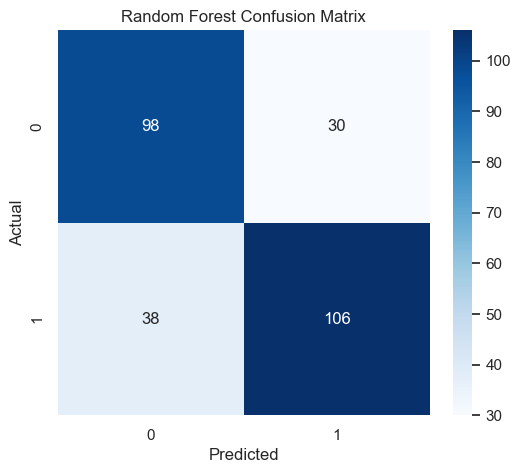

In [132]:
# Random Forest Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_predictions),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [133]:
# SGD Classifier

sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

print("SGD Model Trained Successfully!")

SGD Model Trained Successfully!


In [134]:
sgd_predictions = sgd_model.predict(X_test_scaled)

In [135]:
sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print(f"SGD Accuracy: {sgd_accuracy:.4f}")

SGD Accuracy: 0.7243


In [136]:
print(classification_report(y_test, sgd_predictions))

              precision    recall  f1-score   support

           0       0.70      0.73      0.71       128
           1       0.75      0.72      0.73       144

    accuracy                           0.72       272
   macro avg       0.72      0.72      0.72       272
weighted avg       0.73      0.72      0.72       272



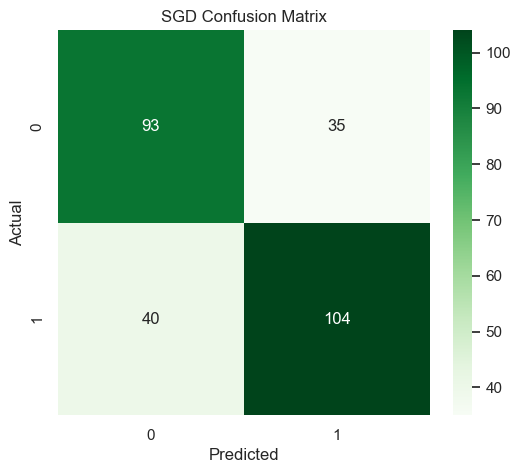

In [137]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, sgd_predictions),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SGD Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [138]:

# Support Vector Classifier

svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

print("SVC Model Trained Successfully!")


SVC Model Trained Successfully!


In [139]:
svc_predictions = svc_model.predict(X_test_scaled)

In [140]:
svc_accuracy = accuracy_score(y_test, svc_predictions)

print(f"SVC Accuracy: {svc_accuracy:.4f}")

SVC Accuracy: 0.7537


In [141]:
print(classification_report(y_test, svc_predictions))

              precision    recall  f1-score   support

           0       0.73      0.77      0.75       128
           1       0.78      0.74      0.76       144

    accuracy                           0.75       272
   macro avg       0.75      0.75      0.75       272
weighted avg       0.76      0.75      0.75       272



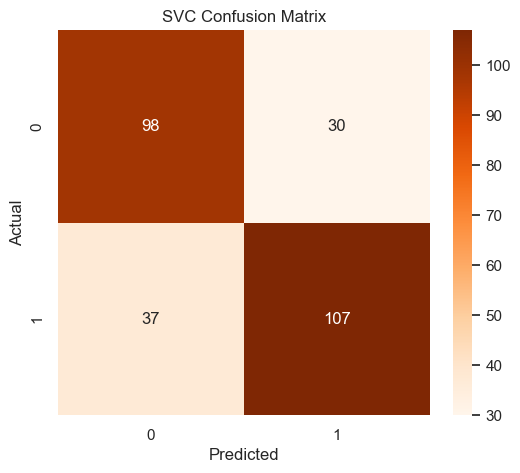

In [142]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, svc_predictions),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("SVC Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

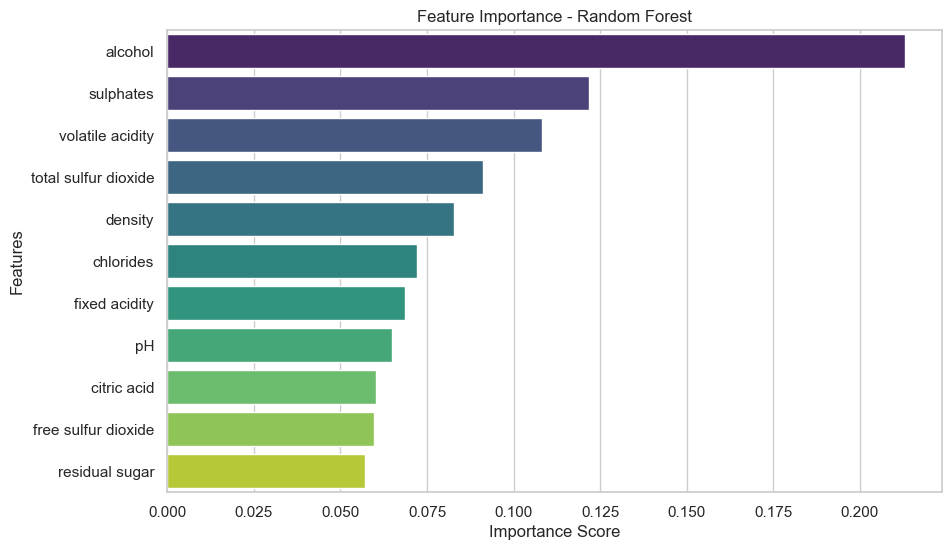

,Feature,Importance
10,alcohol,0.213
9,sulphates,0.122
1,volatile acidity,0.108
6,total sulfur dioxide,0.091
7,density,0.083
4,chlorides,0.072
0,fixed acidity,0.069
8,pH,0.065
2,citric acid,0.060
5,free sulfur dioxide,0.060


In [143]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",          # avoids future seaborn warning
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

feature_importance

In [144]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


comparison

,Model,Accuracy
0,Support Vector Classifier,0.754
1,Random Forest,0.750
2,SGD Classifier,0.724


# Conclusion

In this project, a Wine Quality Prediction system was developed using machine learning techniques. The dataset was explored through Exploratory Data Analysis (EDA), revealing class imbalance in the original quality scores and relationships among physicochemical properties.

To simplify the prediction task, the quality scores were converted into two categories: **Bad Wine** and **Good Wine**. The dataset was then preprocessed using stratified train-test splitting and feature scaling.

Three classification models were trained and evaluated:

- Random Forest Classifier
- Stochastic Gradient Descent (SGD) Classifier
- Support Vector Classifier (SVC)

Among the evaluated models, the **Support Vector Classifier (SVC)** achieved the highest accuracy of **75.37%**, followed closely by the Random Forest Classifier (**75.00%**). The SGD Classifier achieved an accuracy of **72.43%**.

Based on the evaluation results, the **Support Vector Classifier (SVC)** is selected as the most suitable model for predicting wine quality on this dataset because it achieved the best overall performance among the tested models.